In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster

# Load data
df = pd.read_csv("Dataset .csv")
df = df.dropna(subset=['Cuisines'])
df['Cuisine_Primary'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())

print("✅ Data loaded!")
print("Shape:", df.shape)
print("\nTop 10 Cities:")
print(df['City'].value_counts().head(10))
print(f"\nCoordinate ranges:")
print(f"Latitude:  {df['Latitude'].min():.2f} to {df['Latitude'].max():.2f}")
print(f"Longitude: {df['Longitude'].min():.2f} to {df['Longitude'].max():.2f}")

✅ Data loaded!
Shape: (9542, 22)

Top 10 Cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

Coordinate ranges:
Latitude:  -41.33 to 55.98
Longitude: -157.95 to 174.83


In [2]:

city_stats = df.groupby('City').agg(
    Restaurant_Count=('Restaurant Name', 'count'),
    Avg_Rating=('Aggregate rating', 'mean'),
    Avg_Cost=('Average Cost for two', 'mean'),
    Avg_Votes=('Votes', 'mean')
).round(2).sort_values('Restaurant_Count', ascending=False)

print("📊 City Statistics:")
print(city_stats.head(10).to_string())

print("\n🏆 Highest Rated Cities (min 10 restaurants):")
top_rated = city_stats[city_stats['Restaurant_Count'] >= 10].sort_values('Avg_Rating', ascending=False)
print(top_rated.head(5).to_string())

print("\n💰 Most Expensive Cities (avg cost):")
expensive = city_stats[city_stats['Restaurant_Count'] >= 10].sort_values('Avg_Cost', ascending=False)
print(expensive.head(5).to_string())

📊 City Statistics:
              Restaurant_Count  Avg_Rating  Avg_Cost  Avg_Votes
City                                                           
New Delhi                 5473        2.44    596.09     114.81
Gurgaon                   1118        2.65    714.02     118.21
Noida                     1080        2.04    539.49      68.04
Faridabad                  251        1.87    447.61      25.84
Ghaziabad                   25        2.85    602.00      94.64
Bhubaneshwar                21        3.98    678.57     202.05
Guwahati                    21        4.19    821.43     236.38
Lucknow                     21        4.20    859.52     434.76
Ahmedabad                   21        4.16    857.14     584.10
Amritsar                    21        3.69    480.95     174.52

🏆 Highest Rated Cities (min 10 restaurants):
                Restaurant_Count  Avg_Rating  Avg_Cost  Avg_Votes
City                                                             
London                        20   

In [4]:
# Step 3: Interactive Folium Map
import folium
from folium.plugins import HeatMap, MarkerCluster

# Filter valid coordinates
df_map = df[
    (df['Latitude'].between(-90, 90)) &
    (df['Longitude'].between(-180, 180)) &
    (df['Latitude'] != 0) &
    (df['Longitude'] != 0)
].copy()

print(f"Restaurants with valid coordinates: {len(df_map)}")

# Color by rating
def get_color(rating):
    if rating >= 4.5: return 'green'
    elif rating >= 4.0: return 'blue'
    elif rating >= 3.0: return 'orange'
    else: return 'red'

# Create base map
m = folium.Map(
    location=[20.0, 77.0],
    zoom_start=4,
    tiles='CartoDB positron'
)

# Add marker cluster
marker_cluster = MarkerCluster(
    name="Restaurants"
).add_to(m)

# Add markers (sample 2000 for performance)
df_sample = df_map.sample(min(2000, len(df_map)), random_state=42)

for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=get_color(row['Aggregate rating']),
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(f"""
            <b>{row['Restaurant Name']}</b><br>
            🍽️ {row['Cuisine_Primary']}<br>
            ⭐ Rating: {row['Aggregate rating']}<br>
            📍 {row['City']}<br>
            💰 Cost for two: {row['Average Cost for two']}
        """, max_width=200)
    ).add_to(marker_cluster)

# Add heatmap layer
heat_data = [[row['Latitude'], row['Longitude']] 
             for _, row in df_map.iterrows()]
HeatMap(heat_data, name="Density Heatmap", 
        radius=8, blur=10).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Add legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:15px; border-radius:10px;
     box-shadow:0 2px 10px rgba(0,0,0,0.2); font-family:Arial;">
  <b style="font-size:14px">⭐ Rating Legend</b><br><br>
  <i style="color:green">●</i> 4.5+ Excellent<br>
  <i style="color:blue">●</i> 4.0-4.5 Very Good<br>
  <i style="color:orange">●</i> 3.0-4.0 Good<br>
  <i style="color:red">●</i> Below 3.0 Poor<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save("restaurant_map.html")
print("✅ Interactive map saved as 'restaurant_map.html'!")
print("Open it in Chrome to explore! 🗺️")

Restaurants with valid coordinates: 9043
✅ Interactive map saved as 'restaurant_map.html'!
Open it in Chrome to explore! 🗺️


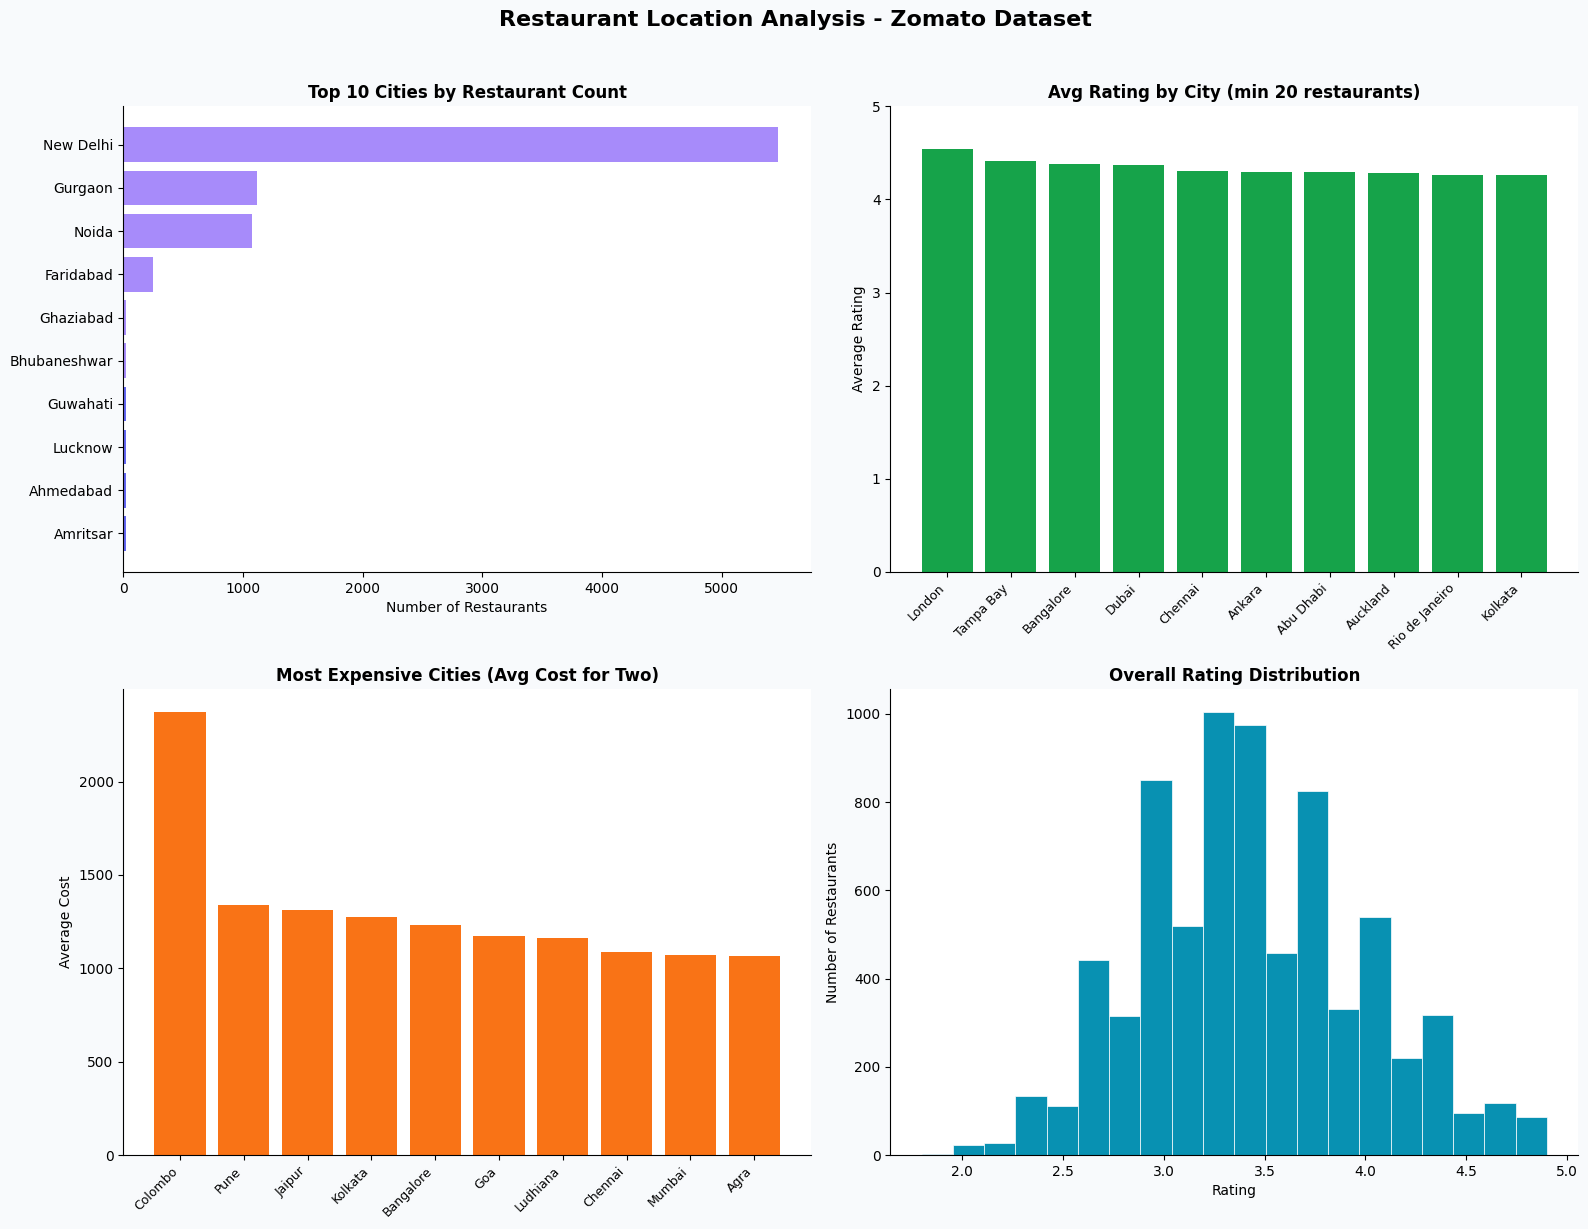

✅ Charts saved as 'location_charts.png'!


In [5]:
# Step 4: City & Locality Analysis Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#f8fafc')
fig.suptitle('Restaurant Location Analysis - Zomato Dataset', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Top 10 cities by restaurant count
top_cities = city_stats.head(10)
axes[0,0].barh(top_cities.index[::-1], 
               top_cities['Restaurant_Count'][::-1],
               color=['#6366f1']*4 + ['#a78bfa']*6)
axes[0,0].set_title('Top 10 Cities by Restaurant Count', fontweight='bold')
axes[0,0].set_xlabel('Number of Restaurants')
axes[0,0].spines[['top','right']].set_visible(False)

# Chart 2: Avg rating by top cities
rated_cities = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Rating', ascending=False).head(10)
colors = ['#16a34a' if r >= 4.0 else '#ca8a04' if r >= 3.0 else '#dc2626' 
          for r in rated_cities['Avg_Rating']]
axes[0,1].bar(range(len(rated_cities)), rated_cities['Avg_Rating'], color=colors)
axes[0,1].set_xticks(range(len(rated_cities)))
axes[0,1].set_xticklabels(rated_cities.index, rotation=45, ha='right', fontsize=9)
axes[0,1].set_title('Avg Rating by City (min 20 restaurants)', fontweight='bold')
axes[0,1].set_ylabel('Average Rating')
axes[0,1].set_ylim(0, 5)
axes[0,1].spines[['top','right']].set_visible(False)

# Chart 3: Avg cost by top cities
cost_cities = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Cost', ascending=False).head(10)
axes[1,0].bar(range(len(cost_cities)), cost_cities['Avg_Cost'], color='#f97316')
axes[1,0].set_xticks(range(len(cost_cities)))
axes[1,0].set_xticklabels(cost_cities.index, rotation=45, ha='right', fontsize=9)
axes[1,0].set_title('Most Expensive Cities (Avg Cost for Two)', fontweight='bold')
axes[1,0].set_ylabel('Average Cost')
axes[1,0].spines[['top','right']].set_visible(False)

# Chart 4: Rating distribution across all restaurants
axes[1,1].hist(df[df['Aggregate rating'] > 0]['Aggregate rating'], 
               bins=20, color='#0891b2', edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Overall Rating Distribution', fontweight='bold')
axes[1,1].set_xlabel('Rating')
axes[1,1].set_ylabel('Number of Restaurants')
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('location_charts.png', dpi=150, bbox_inches='tight',
            facecolor='#f8fafc')
plt.show()
print("✅ Charts saved as 'location_charts.png'!")

In [6]:
# Step 5: Key Insights
print("=" * 55)
print("🌍 KEY INSIGHTS - LOCATION BASED ANALYSIS")
print("=" * 55)

# Insight 1: City dominance
top_city = city_stats.index[0]
top_count = city_stats.iloc[0]['Restaurant_Count']
pct = (top_count / len(df) * 100).round(1)
print(f"\n📍 City Dominance:")
print(f"   {top_city} has {top_count} restaurants ({pct}% of dataset!)")

# Insight 2: Best rated city
best_city = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Rating', ascending=False).index[0]
best_rating = city_stats.loc[best_city, 'Avg_Rating']
print(f"\n⭐ Highest Rated City (min 20 restaurants):")
print(f"   {best_city} with avg rating {best_rating}")

# Insight 3: Most expensive city
exp_city = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Cost', ascending=False).index[0]
exp_cost = city_stats.loc[exp_city, 'Avg_Cost']
print(f"\n💰 Most Expensive City:")
print(f"   {exp_city} with avg cost {exp_cost:.0f} for two")

# Insight 4: Rating vs cost correlation
corr = df[['Aggregate rating', 'Average Cost for two', 
           'Votes', 'Price range']].corr()
print(f"\n📊 Correlation with Rating:")
print(f"   Votes vs Rating:     {corr.loc['Votes','Aggregate rating']:.3f}")
print(f"   Cost vs Rating:      {corr.loc['Average Cost for two','Aggregate rating']:.3f}")
print(f"   Price range vs Rating: {corr.loc['Price range','Aggregate rating']:.3f}")

# Insight 5: Global spread
print(f"\n🌐 Global Spread:")
print(f"   Countries: {df['Country Code'].nunique()}")
print(f"   Cities: {df['City'].nunique()}")
print(f"   Latitude range: {df['Latitude'].min():.1f}° to {df['Latitude'].max():.1f}°")
print(f"   Longitude range: {df['Longitude'].min():.1f}° to {df['Longitude'].max():.1f}°")

# Insight 6: Online delivery by city
delivery_by_city = df[df['Has Online delivery'] == 'Yes'].groupby('City').size().sort_values(ascending=False)
print(f"\n🛵 Online Delivery Leaders:")
print(delivery_by_city.head(5).to_string())

🌍 KEY INSIGHTS - LOCATION BASED ANALYSIS

📍 City Dominance:
   New Delhi has 5473.0 restaurants (57.4% of dataset!)

⭐ Highest Rated City (min 20 restaurants):
   London with avg rating 4.54

💰 Most Expensive City:
   Colombo with avg cost 2375 for two

📊 Correlation with Rating:
   Votes vs Rating:     0.313
   Cost vs Rating:      0.052
   Price range vs Rating: 0.438

🌐 Global Spread:
   Countries: 15
   Cities: 140
   Latitude range: -41.3° to 56.0°
   Longitude range: -157.9° to 174.8°

🛵 Online Delivery Leaders:
City
New Delhi    1489
Gurgaon       425
Noida         364
Faridabad      35
Chennai        13


In [7]:
# Step 6: Generate Final Dashboard
import json
import base64

# Encode chart image
with open("location_charts.png", "rb") as f:
    chart_b64 = base64.b64encode(f.read()).decode()

# Prepare city data for JS charts
top10_cities = city_stats.head(10)
rated_cities = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Rating', ascending=False).head(8)
cost_cities = city_stats[city_stats['Restaurant_Count'] >= 20].sort_values('Avg_Cost', ascending=False).head(8)

html = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Location Analysis | Cognifyz Task 4</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<style>
* { margin:0; padding:0; box-sizing:border-box; }
body { font-family:'Segoe UI',sans-serif; background:#0f172a; color:#e2e8f0; }
.header {
  background:linear-gradient(135deg,#0f766e,#0891b2,#6366f1);
  padding:50px 40px; text-align:center;
}
.header h1 { font-size:2.5rem; font-weight:800; color:white; margin-bottom:10px; }
.header p { color:rgba(255,255,255,0.85); font-size:1.1rem; }
.stats-row { display:flex; gap:16px; padding:30px 40px; justify-content:center; flex-wrap:wrap; }
.stat-card { background:linear-gradient(135deg,#1e293b,#334155); border-radius:16px; padding:24px 32px; text-align:center; border:1px solid #475569; min-width:150px; }
.stat-card .value { font-size:1.8rem; font-weight:800; }
.stat-card .label { font-size:0.82rem; color:#94a3b8; margin-top:6px; }
.ml-info { text-align:center; padding:0 40px 20px; }
.ml-badge { background:linear-gradient(135deg,#0f766e,#0891b2); color:white; padding:5px 14px; border-radius:999px; font-size:0.78rem; font-weight:600; display:inline-block; margin:4px; }
.section { padding:0 40px 40px; }
.section-title { font-size:1.2rem; font-weight:700; color:#2dd4bf; margin-bottom:20px; padding-bottom:10px; border-bottom:2px solid #334155; }
.charts-grid { display:grid; grid-template-columns:1fr 1fr; gap:24px; margin-bottom:30px; }
.chart-card { background:#1e293b; border-radius:16px; padding:24px; border:1px solid #334155; }
.chart-card h3 { font-size:0.9rem; font-weight:700; color:#2dd4bf; margin-bottom:16px; text-transform:uppercase; letter-spacing:0.06em; }
canvas { max-height:280px; }
.insights-grid { display:grid; grid-template-columns:repeat(3,1fr); gap:16px; }
.insight-card { background:#1e293b; border-radius:16px; padding:20px; border:1px solid #334155; animation:fadeIn 0.5s ease forwards; opacity:0; }
@keyframes fadeIn { to { opacity:1; } }
.insight-icon { font-size:2rem; margin-bottom:10px; }
.insight-title { font-size:0.82rem; font-weight:700; color:#94a3b8; text-transform:uppercase; letter-spacing:0.05em; margin-bottom:8px; }
.insight-text { font-size:0.9rem; color:#e2e8f0; line-height:1.6; }
.highlight { color:#2dd4bf; font-weight:700; }
.warning { color:#f97316; font-weight:700; }
.map-section { padding:0 40px 40px; }
.map-card { background:#1e293b; border-radius:16px; padding:24px; border:1px solid #334155; text-align:center; }
.map-btn { display:inline-block; background:linear-gradient(135deg,#0f766e,#0891b2); color:white; padding:14px 32px; border-radius:10px; font-size:1rem; font-weight:700; text-decoration:none; margin-top:16px; transition:opacity 0.2s; }
.map-btn:hover { opacity:0.9; }
.map-preview { width:100%; border-radius:12px; margin-top:16px; border:1px solid #334155; }
.footer { text-align:center; padding:24px; color:#475569; font-size:0.82rem; border-top:1px solid #1e293b; margin-top:10px; }
</style>
</head>
<body>

<div class="header">
  <h1>🗺️ Restaurant Location Analysis</h1>
  <p>Geographical Analysis of Zomato Restaurants | Cognifyz Internship Task 4</p>
</div>

<div class="stats-row">
  <div class="stat-card">
    <div class="value" style="color:#2dd4bf">9,542</div>
    <div class="label">Restaurants</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#60a5fa">15</div>
    <div class="label">Countries</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#a78bfa">140</div>
    <div class="label">Cities</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#f97316">57.4%</div>
    <div class="label">New Delhi Share</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#34d399">4.54⭐</div>
    <div class="label">London Avg Rating</div>
  </div>
</div>

<div class="ml-info">
  <span class="ml-badge">✅ Geographic Distribution</span>
  <span class="ml-badge">✅ City-level Statistics</span>
  <span class="ml-badge">✅ Correlation Analysis</span>
  <span class="ml-badge">✅ Interactive Heatmap</span>
</div>

<div class="section">
  <div class="section-title">📊 City Analysis</div>
  <div class="charts-grid">
    <div class="chart-card">
      <h3>🏙️ Top Cities by Restaurant Count</h3>
      <canvas id="cityCountChart"></canvas>
    </div>
    <div class="chart-card">
      <h3>⭐ Highest Rated Cities</h3>
      <canvas id="ratingChart"></canvas>
    </div>
    <div class="chart-card">
      <h3>💰 Most Expensive Cities</h3>
      <canvas id="costChart"></canvas>
    </div>
    <div class="chart-card">
      <h3>📈 Rating Correlations</h3>
      <canvas id="corrChart"></canvas>
    </div>
  </div>
</div>

<div class="map-section">
  <div class="section-title">🗺️ Interactive Restaurant Map</div>
  <div class="map-card">
    <p style="color:#94a3b8; font-size:1rem;">
      Click the button below to open the fully interactive map with<br>
      <strong style="color:#2dd4bf">2,000 restaurant markers</strong> + 
      <strong style="color:#2dd4bf">heatmap overlay</strong> + 
      <strong style="color:#2dd4bf">clickable popups!</strong>
    </p>
    <a href="restaurant_map.html" target="_blank" class="map-btn">
      🗺️ Open Interactive Map
    </a>
    <br>
    <img src="data:image/png;base64,""" + chart_b64 + """" 
         class="map-preview" alt="Location Charts">
  </div>
</div>

<div class="section">
  <div class="section-title">🔍 Key Geographical Insights</div>
  <div class="insights-grid">
    <div class="insight-card" style="animation-delay:0.1s">
      <div class="insight-icon">🏙️</div>
      <div class="insight-title">City Dominance</div>
      <div class="insight-text"><span class="highlight">New Delhi dominates with 57.4%</span> of all restaurants — 5,473 out of 9,542!</div>
    </div>
    <div class="insight-card" style="animation-delay:0.2s">
      <div class="insight-icon">⭐</div>
      <div class="insight-title">Quality Hotspot</div>
      <div class="insight-text"><span class="highlight">London leads with 4.54 avg rating</span> — international cities tend to have higher standards!</div>
    </div>
    <div class="insight-card" style="animation-delay:0.3s">
      <div class="insight-icon">💰</div>
      <div class="insight-title">Most Expensive</div>
      <div class="insight-text"><span class="warning">Colombo avg cost: 2,375</span> for two — nearly 4x more expensive than New Delhi!</div>
    </div>
    <div class="insight-card" style="animation-delay:0.4s">
      <div class="insight-icon">📊</div>
      <div class="insight-title">Price & Rating</div>
      <div class="insight-text">Price range correlates with rating at <span class="highlight">0.438</span> — pricier restaurants tend to be better rated!</div>
    </div>
    <div class="insight-card" style="animation-delay:0.5s">
      <div class="insight-icon">🌐</div>
      <div class="insight-title">Global Reach</div>
      <div class="insight-text">Dataset spans <span class="highlight">15 countries & 140 cities</span> — from Hawaii (-157°) to New Zealand (174°)!</div>
    </div>
    <div class="insight-card" style="animation-delay:0.6s">
      <div class="insight-icon">🛵</div>
      <div class="insight-title">Delivery Hub</div>
      <div class="insight-text"><span class="highlight">New Delhi leads online delivery</span> with the most delivery-enabled restaurants by far!</div>
    </div>
  </div>
</div>

<div class="footer">
  Built by Harini | Cognifyz Internship Task 4 | Location-based Restaurant Analysis
</div>

<script>
// City count chart
new Chart(document.getElementById('cityCountChart'), {
  type: 'bar',
  data: {
    labels: """ + json.dumps(top10_cities.index.tolist()) + """,
    datasets: [{ 
      data: """ + json.dumps(top10_cities['Restaurant_Count'].tolist()) + """,
      backgroundColor: ['#0f766e','#0891b2','#6366f1','#8b5cf6',
                        '#2dd4bf','#60a5fa','#a78bfa','#34d399','#fbbf24','#f97316'],
      borderRadius: 6
    }]
  },
  options: {
    indexAxis: 'y',
    animation: { duration:1500, easing:'easeOutQuart' },
    plugins: { legend: { display:false } },
    scales: {
      x: { ticks:{color:'#94a3b8'}, grid:{color:'#334155'} },
      y: { ticks:{color:'#e2e8f0', font:{size:10}}, grid:{display:false} }
    }
  }
});

// Rating chart
new Chart(document.getElementById('ratingChart'), {
  type: 'bar',
  data: {
    labels: """ + json.dumps(rated_cities.index.tolist()) + """,
    datasets: [{
      data: """ + json.dumps(rated_cities['Avg_Rating'].tolist()) + """,
      backgroundColor: '#34d399',
      borderRadius: 6
    }]
  },
  options: {
    animation: { duration:1500, easing:'easeOutQuart' },
    plugins: { legend:{display:false} },
    scales: {
      x: { ticks:{color:'#94a3b8', font:{size:9}}, grid:{display:false} },
      y: { min:3.5, max:5, ticks:{color:'#94a3b8'}, grid:{color:'#334155'} }
    }
  }
});

// Cost chart
new Chart(document.getElementById('costChart'), {
  type: 'bar',
  data: {
    labels: """ + json.dumps(cost_cities.index.tolist()) + """,
    datasets: [{
      data: """ + json.dumps(cost_cities['Avg_Cost'].tolist()) + """,
      backgroundColor: '#f97316',
      borderRadius: 6
    }]
  },
  options: {
    animation: { duration:1500, easing:'easeOutQuart' },
    plugins: { legend:{display:false} },
    scales: {
      x: { ticks:{color:'#94a3b8', font:{size:9}}, grid:{display:false} },
      y: { ticks:{color:'#94a3b8'}, grid:{color:'#334155'} }
    }
  }
});

// Correlation chart
new Chart(document.getElementById('corrChart'), {
  type: 'bar',
  data: {
    labels: ['Votes vs Rating', 'Cost vs Rating', 'Price Range vs Rating'],
    datasets: [{
      data: [0.313, 0.052, 0.438],
      backgroundColor: ['#6366f1', '#0891b2', '#2dd4bf'],
      borderRadius: 6
    }]
  },
  options: {
    animation: { duration:1500, easing:'easeOutQuart' },
    plugins: { legend:{display:false} },
    scales: {
      x: { ticks:{color:'#94a3b8', font:{size:10}}, grid:{display:false} },
      y: { min:0, max:0.5, ticks:{color:'#94a3b8'}, grid:{color:'#334155'} }
    }
  }
});

// Animate insight cards
setTimeout(() => {
  document.querySelectorAll('.insight-card').forEach((card, i) => {
    setTimeout(() => card.style.opacity = '1', i * 100);
  });
}, 300);
</script>
</body>
</html>"""

with open("location_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Dashboard created!")
print("Open 'location_dashboard.html' in Chrome!")

✅ Dashboard created!
Open 'location_dashboard.html' in Chrome!
